<a href="https://colab.research.google.com/github/jcmachicao/IA_politicaspublicas/blob/main/aipp___ejemplo_sencillo_RL___v2_expandido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicando el Aprendizaje por Refuerzo a la Iluminación Pública

Tu propuesta es muy interesante y un excelente ejemplo de cómo el RL puede ser aplicado a problemas de políticas públicas. Aquí te detallo los componentes clave para modelar este problema:

## 1. El Agente (Agent)
El agente sería el sistema de control que toma decisiones sobre la iluminación de los espacios públicos. Su objetivo es maximizar una recompensa acumulada a lo largo del tiempo, equilibrando factores como el ahorro de energía/presupuesto, la seguridad y el bienestar ciudadano.

## 2. El Entorno (Environment)
El entorno es el espacio público (una calle, un parque, una plaza) con sus dinámicas. Incluye factores como la hora del día, las condiciones climáticas, la presencia de personas, los eventos, el historial de criminalidad, etc.

## 3. El Estado (State)
El estado (observación) que el agente percibe del entorno en un momento dado. Este debe contener toda la información relevante para que el agente tome una buena decisión. Podría incluir:
*   **Hora del día/Noche:** Fundamental para decidir si encender las luces.
*   **Condiciones climáticas:** Lluvia, niebla, oscuridad natural adicional.
*   **Nivel de luz ambiental:** Sensores de luz natural.
*   **Presencia de personas:** Detectores de movimiento, cámaras (anonimizadas).
*   **Nivel de actividad:** Datos históricos o en tiempo real de uso del espacio.
*   **Índices de seguridad:** Datos históricos de incidentes en la zona.
*   **Presupuesto disponible:** Restricciones o saldo actual del presupuesto energético.
*   **Estado actual de las luces:** Encendidas/Apagadas, nivel de intensidad.

**Ejemplo de estado:**

`[hora_actual, es_noche, hay_lluvia, personas_detectadas, indice_criminalidad_zona, presupuesto_restante, luz_actualmente_encendida]`

## 4. Las Acciones (Actions)
Las acciones que el agente puede tomar para influir en el entorno. Podrían ser:
*   **Encender/Apagar las luces:** Una acción binaria.
*   **Ajustar la intensidad:** Niveles discretos o continuos de brillo.
*   **Mantener el estado actual:** No hacer nada.
*   **Ajustar horarios preestablecidos:** Modificar un horario programado.

**Ejemplo de acciones:**

`[encender, apagar, aumentar_intensidad, disminuir_intensidad, no_hacer_nada]`

## 5. La Recompensa (Reward)
La recompensa es la señal que el agente recibe del entorno después de realizar una acción, indicando cuán buena fue esa acción. Se construye combinando los objetivos de la política pública:
*   **Recompensa Positiva:**
    *   `+1` por seguridad (si la iluminación disuade el crimen, o si la presencia de luz se correlaciona con menos incidentes).
    *   `+1` por bienestar (si la gente usa más el espacio o se siente más segura).
    *   `+0.5` por uso eficiente (si las luces están encendidas cuando hay gente presente y son necesarias).
*   **Recompensa Negativa (Castigo):**
    *   `-X` por consumo de energía/presupuesto (un costo por mantener las luces encendidas, proporcional al tiempo y la intensidad).
    *   `-Y` por inseguridad (si las luces están apagadas y ocurre un incidente, o si la oscuridad contribuye a la percepción de inseguridad).
    *   `-Z` por disconfort (luces encendidas sin necesidad, generando contaminación lumínica o molestia).

La función de recompensa sería una suma ponderada de estos factores. Por ejemplo:

`reward = (seguridad_score * w1) + (bienestar_score * w2) - (costo_energia * w3) - (riesgo_inseguridad * w4)`

## 6. La Política (Policy)
La política es la estrategia que el agente usa para seleccionar una acción dado un estado. El objetivo del entrenamiento de RL es aprender la política óptima que maximice la recompensa acumulada a largo plazo.

## Desafíos y Consideraciones:
*   **Recopilación de Datos:** Necesitarías datos históricos y en tiempo real para el estado y para evaluar la recompensa (ej. sensores de presencia, medidores de energía, reportes de incidentes, encuestas de percepción).
*   **Simulación:** Sería ideal construir un entorno de simulación para entrenar al agente antes de implementarlo en el mundo real, dadas las implicaciones de seguridad y presupuesto.
*   **Exploración vs. Explotación:** El agente debe equilibrar entre explorar nuevas estrategias de iluminación y explotar las que ya sabe que funcionan bien.
*   **Multi-objetivo:** La función de recompensa debe ser cuidadosamente diseñada para balancear los objetivos a menudo conflictivos de presupuesto, seguridad y bienestar.

Este es un caso de uso muy prometedor para el RL en políticas públicas. ¡Definitivamente es una gran idea para explorar!'''

## 7. Definición de Clases Básicas para el Modelo RL

In [1]:
ruta = "drive/My Drive/00 2026_all/2027 Cursos/"

In [2]:
import random

class Environment:
    def __init__(self):
        # Inicializar el estado del entorno (e.g., hora, clima, presencia de personas)
        self.current_state = self._get_initial_state()

    def _get_initial_state(self):
        # Define el estado inicial del entorno. Esto es un ejemplo.
        # [hora_actual, es_noche, hay_lluvia, personas_detectadas, indice_criminalidad_zona, presupuesto_restante, luz_actualmente_encendida]
        return State(hour=18, is_night=True, raining=False, people_detected=5, crime_index=0.1, budget=1000, light_on=False, intensity=0)

    def step(self, action):
        # Aplica una acción y actualiza el estado del entorno, calcula la recompensa
        old_state = self.current_state
        new_state = self._update_state(old_state, action)
        reward = self._calculate_reward(old_state, action, new_state)
        self.current_state = new_state
        done = self._is_terminal(new_state) # Define si el episodio ha terminado
        return new_state, reward, done

    def _update_state(self, old_state, action):
        # Lógica para actualizar el estado basada en la acción
        # Esto es un placeholder; la lógica real sería más compleja
        new_hour = (old_state.hour + 1) % 24
        new_light_on = old_state.light_on
        new_intensity = old_state.intensity

        if action.type == 'turn_on':
            new_light_on = True
            new_intensity = action.value if action.value is not None else 100 # Asume intensidad máxima por defecto
        elif action.type == 'turn_off':
            new_light_on = False
            new_intensity = 0
        elif action.type == 'adjust_intensity':
            new_intensity = action.value
            new_light_on = (new_intensity > 0)

        # Simular algunos cambios aleatorios en el entorno para el ejemplo
        new_people_detected = max(0, old_state.people_detected + random.randint(-2, 2))
        new_crime_index = max(0.0, min(1.0, old_state.crime_index + random.uniform(-0.05, 0.05)))
        new_budget = old_state.budget - (new_intensity * 0.1) # Costo simplificado

        return State(
            hour=new_hour,
            is_night=(new_hour < 6 or new_hour > 18),
            raining=old_state.raining, # Podría cambiar con el tiempo
            people_detected=new_people_detected,
            crime_index=new_crime_index,
            budget=new_budget,
            light_on=new_light_on,
            intensity=new_intensity
        )

    def _calculate_reward(self, old_state, action, new_state):
        # Implementar la función de recompensa ponderada aquí
        # reward = (seguridad_score * w1) + (bienestar_score * w2) - (costo_energia * w3) - (riesgo_inseguridad * w4)
        reward = 0

        # Penalización base por costo de luz
        cost_of_light = (new_state.intensity * 0.1)
        reward -= cost_of_light

        # Recompensas/Penalizaciones relacionadas con la seguridad y bienestar
        # Aumentamos el peso de tener las luces encendidas cuando hay gente y es de noche
        if new_state.is_night and new_state.people_detected > 0:
            if new_state.light_on:
                reward += 2.0  # Mayor recompensa por seguridad y bienestar cuando es necesario
            else:
                reward -= 1.5  # Mayor penalización por no encender las luces cuando hay gente y es de noche

        # Penalización si las luces están encendidas sin necesidad (ej. sin gente o de día)
        if new_state.light_on and (new_state.people_detected == 0 or not new_state.is_night):
            reward -= 0.7  # Penalización por desperdicio de energía/contaminación lumínica

        # Recompensa por ahorro cuando no hay nadie y es de noche
        if not new_state.light_on and new_state.people_detected == 0 and new_state.is_night:
            reward += 0.5

        # Recompensas/Penalizaciones relacionadas con el crimen
        if new_state.crime_index < old_state.crime_index:
            reward += 0.3 # Mayor recompensa por reducción del crimen
        elif new_state.crime_index > old_state.crime_index:
            reward -= 0.3 # Mayor penalización por aumento del crimen

        return reward

    def _is_terminal(self, state):
        # Define cuándo termina un episodio (e.g., presupuesto agotado, tiempo límite)
        return state.budget <= 0 or state.hour == 23 # Ejemplo: fin del día o sin presupuesto

    def reset(self):
        self.current_state = self._get_initial_state()
        return self.current_state

    def render(self):
        print(f"Current State: {self.current_state}")

In [3]:
class State:
    def __init__(self, hour, is_night, raining, people_detected, crime_index, budget, light_on, intensity):
        self.hour = hour
        self.is_night = is_night
        self.raining = raining
        self.people_detected = people_detected
        self.crime_index = crime_index
        self.budget = budget
        self.light_on = light_on
        self.intensity = intensity

    def __repr__(self):
        return (
            f"State(Hour={self.hour}, Night={self.is_night}, Rain={self.raining}, "
            f"People={self.people_detected}, Crime={self.crime_index:.2f}, "
            f"Budget={self.budget:.2f}, LightOn={self.light_on}, Intensity={self.intensity})"
        )

    def to_tuple(self):
        # Convierte el estado a una tupla inmutable para usarlo como clave en diccionarios (Q-table)
        return (self.hour, self.is_night, self.raining, self.people_detected,
                round(self.crime_index, 1), round(self.budget, 0), self.light_on, self.intensity)

In [4]:
class Action:
    def __init__(self, type, value=None):
        # type puede ser 'turn_on', 'turn_off', 'adjust_intensity', 'do_nothing'
        # value se usa para 'adjust_intensity' (e.g., 0-100)
        self.type = type
        self.value = value

    def __repr__(self):
        if self.value is not None:
            return f"Action({self.type}, value={self.value})"
        return f"Action({self.type})"

    def __eq__(self, other):
        if not isinstance(other, Action):
            return NotImplemented
        return self.type == other.type and self.value == other.value

    def __hash__(self):
        return hash((self.type, self.value))

In [5]:
class Agent:
    def __init__(self, environment):
        self.environment = environment
        self.possible_actions = self._get_possible_actions() # Lista de todas las acciones posibles

    def _get_possible_actions(self):
        # Define todas las acciones discretas que el agente puede tomar
        actions = [
            Action('turn_on', 100), # Encender al 100%
            Action('turn_off'),
            Action('adjust_intensity', 25),
            Action('adjust_intensity', 50),
            Action('adjust_intensity', 75),
            Action('do_nothing')
        ]
        return actions

    def choose_action(self, state):
        # Esta es la parte central del agente RL. En un agente real,
        # usaría una política (ej. Q-table, red neuronal) para elegir la acción.
        # Por ahora, elegiremos una acción aleatoria para el ejemplo.
        return random.choice(self.possible_actions)

    def learn(self, old_state, action, reward, new_state, done):
        # En un agente real, aquí se actualizarían los pesos de la red neuronal
        # o los valores de la Q-table basados en la experiencia (old_state, action, reward, new_state)
        pass

## 8. Implementación del Agente Q-Learning

# New Section

In [6]:
import numpy as np
from collections import defaultdict

class QLearningAgent(Agent):
    def __init__(self, environment, learning_rate=0.1, discount_factor=0.9, epsilon=0.1, epsilon_decay_rate=0.995, min_epsilon=0.01):
        super().__init__(environment)
        self.q_table = defaultdict(lambda: np.zeros(len(self.possible_actions))) # Q-table: (state_tuple) -> [q_value_action1, ...]
        self.learning_rate = learning_rate  # Alpha
        self.discount_factor = discount_factor # Gamma
        self.epsilon = epsilon  # Epsilon para la política epsilon-greedy
        self.epsilon_decay_rate = epsilon_decay_rate
        self.min_epsilon = min_epsilon

    def choose_action(self, state):
        state_tuple = state.to_tuple()
        # Política epsilon-greedy
        if random.uniform(0, 1) < self.epsilon:
            # Exploración: elige una acción aleatoria
            return random.choice(self.possible_actions)
        else:
            # Explotación: elige la acción con el mayor Q-value
            q_values = self.q_table[state_tuple]
            # Encontrar el índice de la acción con el Q-value máximo
            max_q = -float('inf')
            best_action_indices = []
            for i, q_val in enumerate(q_values):
                if q_val > max_q:
                    max_q = q_val
                    best_action_indices = [i]
                elif q_val == max_q:
                    best_action_indices.append(i)

            # Si hay múltiples acciones con el mismo Q-value máximo, elige una al azar
            chosen_action_index = random.choice(best_action_indices)
            return self.possible_actions[chosen_action_index]

    def learn(self, old_state, action, reward, new_state, done):
        old_state_tuple = old_state.to_tuple()
        new_state_tuple = new_state.to_tuple()

        # Encuentra el índice de la acción tomada en la lista de acciones posibles
        action_index = self.possible_actions.index(action)

        # Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        old_q_value = self.q_table[old_state_tuple][action_index]

        if done:
            # Si es un estado terminal, no hay futuro (max(Q(s',a')) = 0)
            max_future_q = 0
        else:
            # Estima el valor Q máximo para el nuevo estado
            max_future_q = np.max(self.q_table[new_state_tuple])

        new_q_value = old_q_value + self.learning_rate * (reward + self.discount_factor * max_future_q - old_q_value)
        self.q_table[old_state_tuple][action_index] = new_q_value

        # Decay epsilon
        if done:
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay_rate)

## 9. Simulación de Entrenamiento

Episode 0: Total Reward = -23.200000000000003, Epsilon = 0.0995
Episode 100: Total Reward = -8.4, Epsilon = 0.0603
Episode 200: Total Reward = -13.599999999999998, Epsilon = 0.0365
Episode 300: Total Reward = -13.399999999999999, Epsilon = 0.0221
Episode 400: Total Reward = -7.6000000000000005, Epsilon = 0.0134

Entrenamiento terminado.


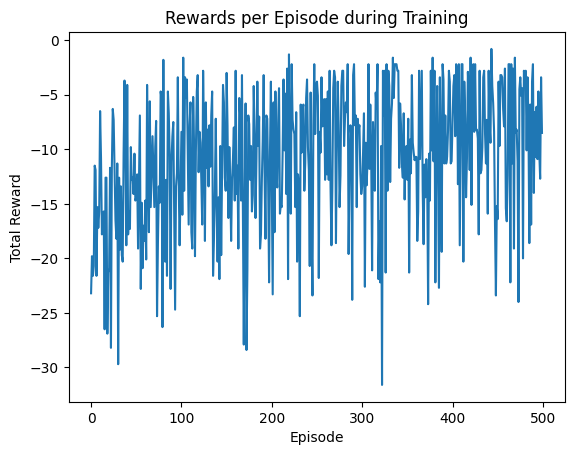

In [7]:
env = Environment()
agent = QLearningAgent(env)

num_episodes = 500
rewards_per_episode = []

for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = agent.choose_action(state)
        new_state, reward, done = env.step(action)
        agent.learn(state, action, reward, new_state, done)
        state = new_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    if episode % 100 == 0:
        print(f"Episode {episode}: Total Reward = {total_reward}, Epsilon = {agent.epsilon:.4f}")

print("\nEntrenamiento terminado.")

# Opcional: Visualizar los resultados del entrenamiento
import matplotlib.pyplot as plt

plt.plot(rewards_per_episode)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Rewards per Episode during Training")
plt.show()



In [8]:
# Demostrar el agente entrenado
print("\nDemostración del agente entrenado:")
agent.epsilon = 0 # Desactivar exploración para la demostración
state = env.reset()
done = False

while not done:
    env.render()
    action = agent.choose_action(state)
    print(f"Agent chooses: {action}")
    new_state, reward, done = env.step(action)
    state = new_state
    print(f"New state: {state}, Reward: {reward:.2f}, Done: {done}\n")
    if state.budget <= 0:
      print("Presupuesto agotado. Fin de la demostración.")
      break
    if state.hour >= 23:
      print("Fin del día. Fin de la demostración.")
      break


Demostración del agente entrenado:
Current State: State(Hour=18, Night=True, Rain=False, People=5, Crime=0.10, Budget=1000.00, LightOn=False, Intensity=0)
Agent chooses: Action(adjust_intensity, value=25)
New state: State(Hour=19, Night=True, Rain=False, People=7, Crime=0.08, Budget=997.50, LightOn=True, Intensity=25), Reward: -0.20, Done: False

Current State: State(Hour=19, Night=True, Rain=False, People=7, Crime=0.08, Budget=997.50, LightOn=True, Intensity=25)
Agent chooses: Action(do_nothing)
New state: State(Hour=20, Night=True, Rain=False, People=9, Crime=0.07, Budget=995.00, LightOn=True, Intensity=25), Reward: -0.20, Done: False

Current State: State(Hour=20, Night=True, Rain=False, People=9, Crime=0.07, Budget=995.00, LightOn=True, Intensity=25)
Agent chooses: Action(adjust_intensity, value=25)
New state: State(Hour=21, Night=True, Rain=False, People=7, Crime=0.08, Budget=992.50, LightOn=True, Intensity=25), Reward: -0.80, Done: False

Current State: State(Hour=21, Night=True

## 10. Extracción e Interpretación de la Política Aprendida

In [9]:
import pandas as pd

# Crear una lista para almacenar los datos de la política
policy_data = []

# Iterar sobre la q_table para extraer el estado, la acción óptima y su Q-value
for state_tuple, q_values_array in agent.q_table.items():
    # Encontrar el índice de la acción con el mayor Q-value
    best_action_index = np.argmax(q_values_array)
    optimal_action = agent.possible_actions[best_action_index]
    max_q_value = q_values_array[best_action_index]

    # Reconstruir el estado a partir de la tupla
    state = State(*state_tuple) # Asumiendo que la tupla del estado se puede desempaquetar así

    policy_data.append({
        'Hour': state.hour,
        'Is_Night': state.is_night,
        'Raining': state.raining,
        'People_Detected': state.people_detected,
        'Crime_Index': state.crime_index,
        'Budget': state.budget,
        'Light_On': state.light_on,
        'Intensity': state.intensity,
        'Optimal_Action_Type': optimal_action.type,
        'Optimal_Action_Value': optimal_action.value,
        'Max_Q_Value': max_q_value
    })

# Crear un DataFrame de Pandas
policy_df = pd.DataFrame(policy_data)

# Mostrar las primeras filas del DataFrame de la política
display(policy_df.head())

# Mostrar el tamaño de la política aprendida (cuántos estados únicos se exploraron)
print(f"Tamaño de la política aprendida (estados únicos): {len(policy_df)}")


,Hour,Is_Night,Raining,People_Detected,Crime_Index,Budget,Light_On,Intensity,Optimal_Action_Type,Optimal_Action_Value,Max_Q_Value
0,18,True,False,5,0.1,1000.0,False,0,adjust_intensity,25.0,-1.188311
1,19,True,False,5,0.1,990.0,True,100,turn_off,NaN,0.000000
2,20,True,False,3,0.2,982.0,True,75,turn_on,100.0,0.000000
3,21,True,False,1,0.2,978.0,True,50,turn_off,NaN,0.020000
4,22,True,False,0,0.2,978.0,False,0,turn_on,100.0,0.000000


Tamaño de la política aprendida (estados únicos): 662


In [11]:
policy_df.to_excel(ruta + 'policy_data.xlsx', index=False)

Árbol de Decisión entrenado para interpretar la política.

Reglas de la política extraídas (formato de texto):

|--- Intensity <= 37.50
|   |--- Hour <= 19.50
|   |   |--- Budget <= 999.00
|   |   |   |--- class: do_nothing
|   |   |--- Budget >  999.00
|   |   |   |--- class: adjust_intensity
|   |--- Hour >  19.50
|   |   |--- Intensity <= 12.50
|   |   |   |--- class: turn_on
|   |   |--- Intensity >  12.50
|   |   |   |--- class: turn_on
|--- Intensity >  37.50
|   |--- Intensity <= 62.50
|   |   |--- Budget <= 989.00
|   |   |   |--- class: turn_on
|   |   |--- Budget >  989.00
|   |   |   |--- class: turn_on
|   |--- Intensity >  62.50
|   |   |--- People_Detected <= 5.50
|   |   |   |--- class: turn_on
|   |   |--- People_Detected >  5.50
|   |   |   |--- class: turn_on



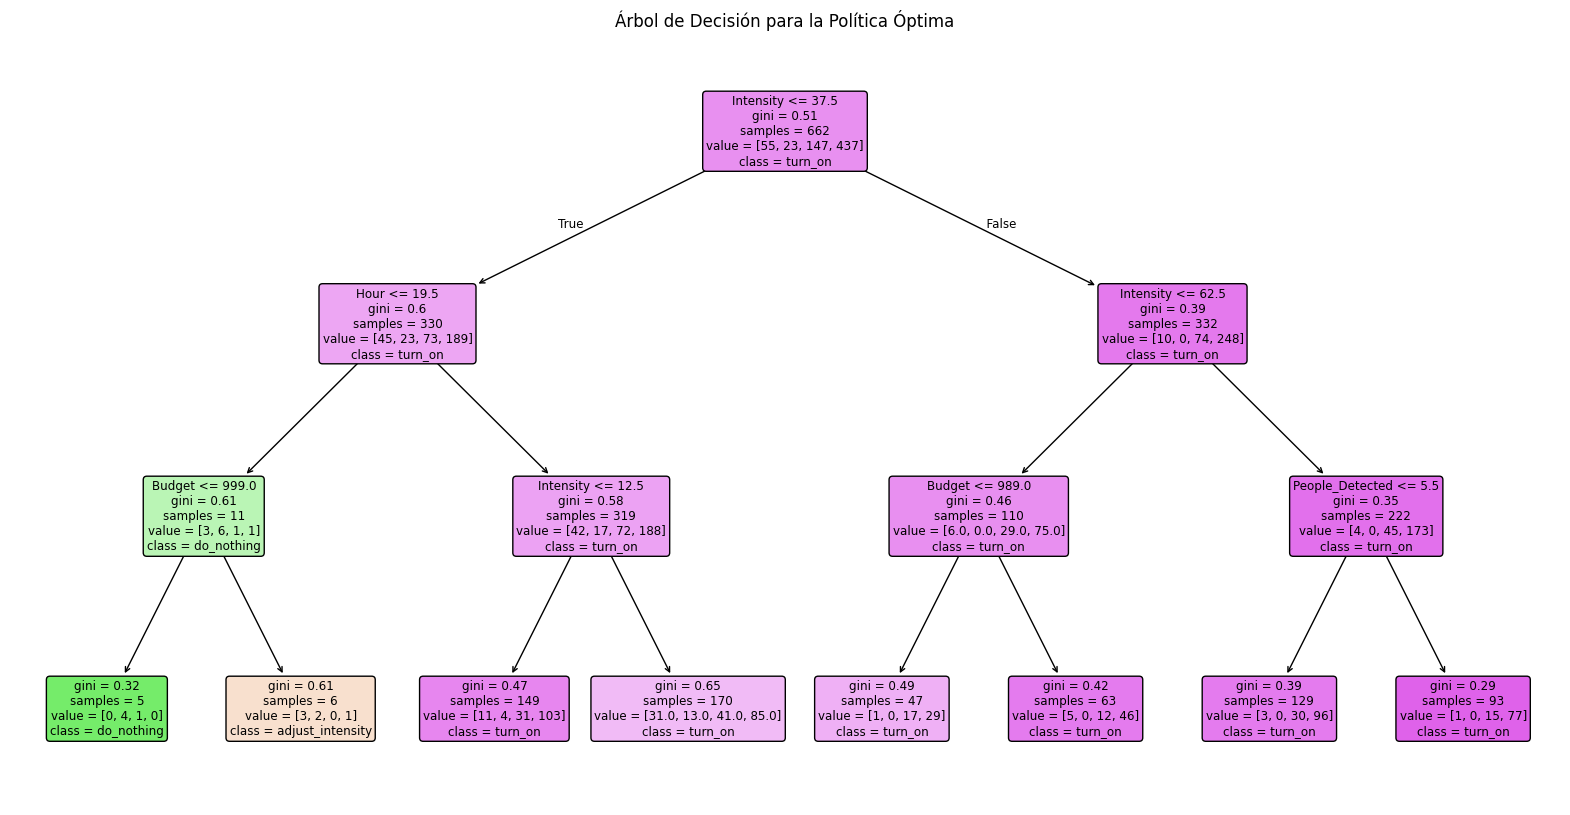


Para generar recomendaciones narrativas, se pueden traducir estas reglas a lenguaje natural.

Por ejemplo, una regla podría ser: 'Si es de noche y no hay personas detectadas, entonces la acción óptima es apagar las luces.'


In [10]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Preparar los datos para el árbol de decisión
# X serán las características del estado, y será la acción óptima

# Seleccionar las características del estado para el entrenamiento
features = ['Hour', 'Is_Night', 'Raining', 'People_Detected', 'Crime_Index', 'Budget', 'Light_On', 'Intensity']
X = policy_df[features].copy()
y = policy_df['Optimal_Action_Type'].copy()

# Convertir las acciones (target) a valores numéricos si es necesario (Label Encoding)
# Esto es útil para algunos clasificadores, aunque DecisionTreeClassifier puede manejar strings
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Opcional: Dividir los datos en conjuntos de entrenamiento y prueba (no estrictamente necesario para interpretación de la política ya aprendida)
# X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Crear y entrenar el árbol de decisión
# Ajusta la profundidad máxima para que sea más interpretable
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
# Para interpretación, entrenamos con todos los datos de la política extraída
dtree.fit(X, y_encoded)

print("Árbol de Decisión entrenado para interpretar la política.\n")

print("Reglas de la política extraídas (formato de texto):\n")
# Exportar las reglas del árbol como texto
r = export_text(dtree, feature_names=list(X.columns), class_names=list(le.classes_))
print(r)

# También podemos visualizar el árbol (requiere matplotlib y graphviz opcionalmente)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtree, filled=True, feature_names=list(X.columns), class_names=list(le.classes_), rounded=True, precision=2)
plt.title("Árbol de Decisión para la Política Óptima")
plt.show()

print("\nPara generar recomendaciones narrativas, se pueden traducir estas reglas a lenguaje natural.\n")
print("Por ejemplo, una regla podría ser: 'Si es de noche y no hay personas detectadas, entonces la acción óptima es apagar las luces.'")

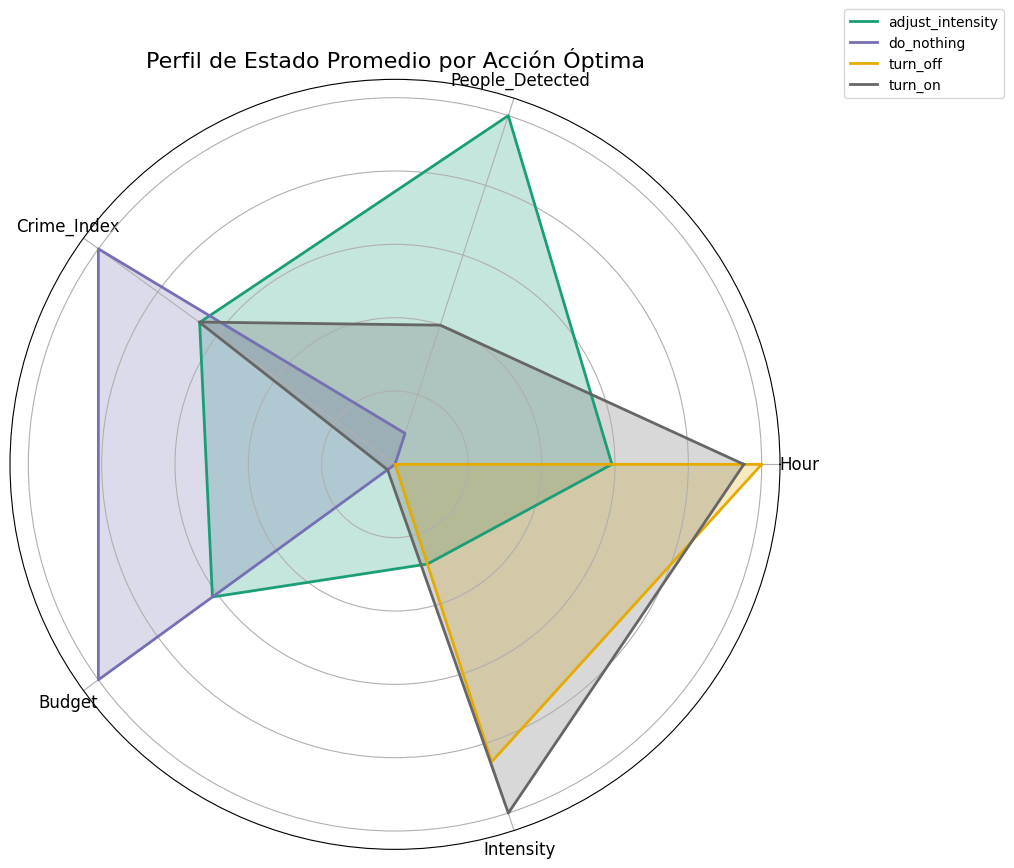

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Agrupar el DataFrame por la acción óptima y calcular el promedio de las características numéricas
# Excluir las columnas booleanas y las que no son relevantes para el radar (como 'Optimal_Action_Value', 'Max_Q_Value')
features_for_radar = ['Hour', 'People_Detected', 'Crime_Index', 'Budget', 'Intensity']

# Asegurarse de que las columnas booleanas sean numéricas (0 o 1) si se quieren incluir,
# pero para el radar es mejor enfocarse en las continuas/ordinales.
policy_df_numeric = policy_df[features_for_radar + ['Optimal_Action_Type']].copy()

# Agrupar y calcular la media
avg_features_by_action = policy_df_numeric.groupby('Optimal_Action_Type')[features_for_radar].mean()

# Normalizar los datos para el gráfico de radar (min-max scaling) A TRAVÉS DE LAS CARACTERÍSTICAS (columnas)
# Esto asegura que todas las características estén en una escala comparable (0 a 1) para cada acción
normalized_features = (avg_features_by_action - avg_features_by_action.min()) / (avg_features_by_action.max() - avg_features_by_action.min())

# Rellenar cualquier NaN que pueda surgir si una columna tiene un solo valor y min==max
normalized_features = normalized_features.fillna(0.5) # Asigna un valor medio si no hay variación


# Preparar los datos para el radar chart
categories = list(normalized_features.columns)
N = len(categories)

# Calcular el ángulo para cada eje
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Cierra el círculo

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# CORRECCIÓN DE ERROR: TypeError en plt.colormaps.get_cmap
# plt.colormaps.get_cmap() no acepta un segundo argumento para el número de colores.
# Primero obtenemos el objeto colormap y luego generamos una lista de colores a partir de él.
cmap = plt.colormaps.get_cmap('Dark2')
num_actions = len(normalized_features.index)
# Generar una lista de colores discretos del colormap.
# Se añade una condición para evitar división por cero si solo hay una acción.
colors_list = [cmap(i / (num_actions - 1)) if num_actions > 1 else cmap(0.5) for i in range(num_actions)]

i = 0
for action_type, row in normalized_features.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]
    # Usar el color de la lista `colors_list` por índice `i`
    ax.plot(angles, values, color=colors_list[i], linewidth=2, linestyle='solid', label=action_type)
    ax.fill(angles, values, color=colors_list[i], alpha=0.25)
    i += 1

ax.set_yticklabels([]) # No mostrar etiquetas de escala radial
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)

ax.set_title('Perfil de Estado Promedio por Acción Óptima', va='bottom', fontsize=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

### Ejemplo de Interpretación y Recomendación Narrativa

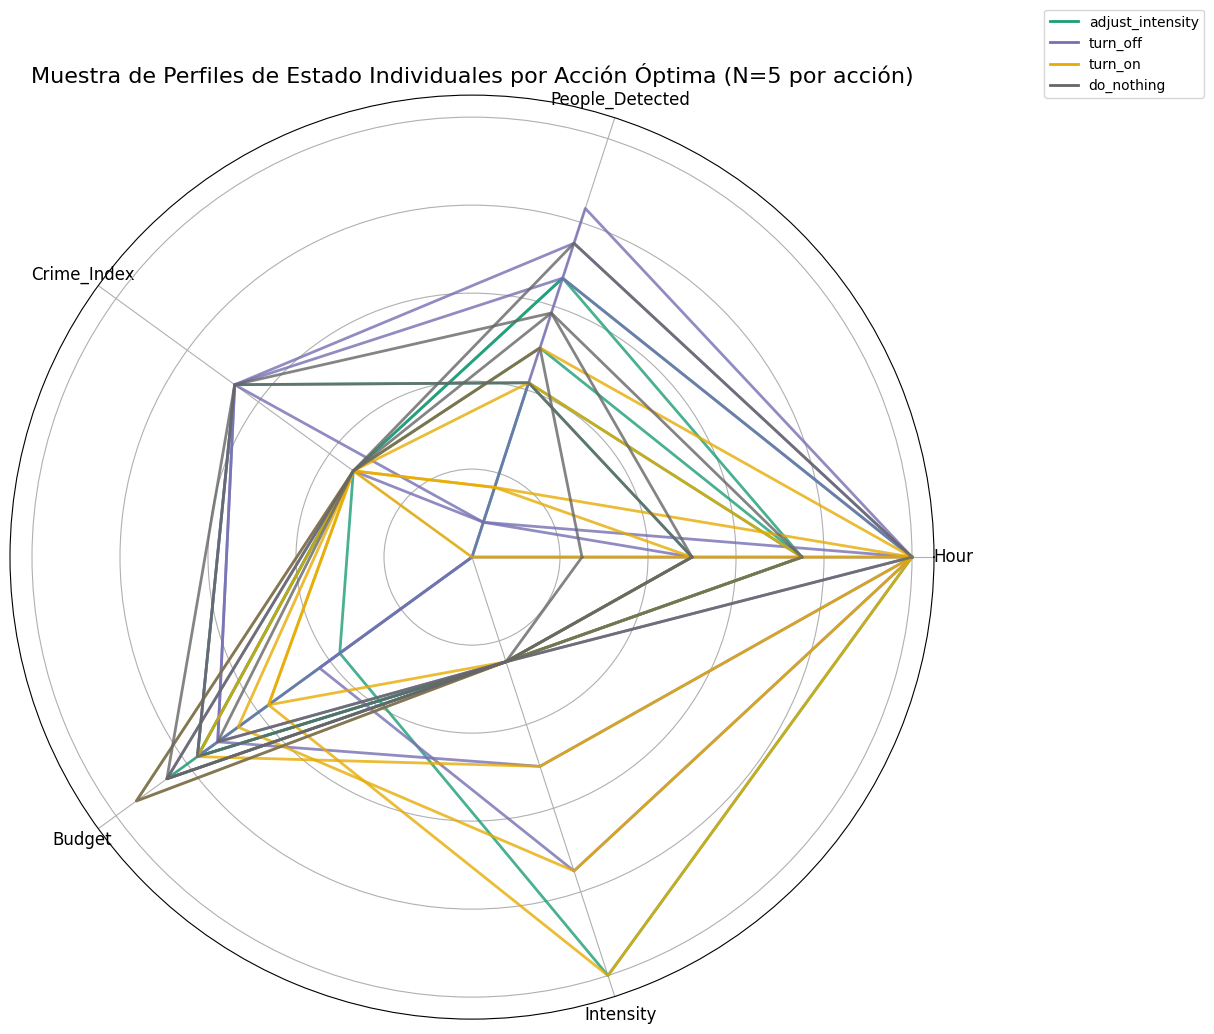

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Seleccionar las características del estado para el radar
features_for_radar = ['Hour', 'People_Detected', 'Crime_Index', 'Budget', 'Intensity']

# Preparar los datos: extraemos solo las características y la acción óptima
data_to_plot = policy_df[features_for_radar + ['Optimal_Action_Type']].copy()

# Normalizar todas las características de forma MIN-MAX a través de TODO el dataset
# Esto es crucial para que cada eje del radar tenga un significado consistente
for feature in features_for_radar:
    min_val = policy_df[feature].min()
    max_val = policy_df[feature].max()
    # Evitar división por cero si una columna tiene un único valor
    if (max_val - min_val) == 0:
        data_to_plot[feature] = 0.5 # Asignar un valor medio si no hay variacion
    else:
        data_to_plot[feature] = (policy_df[feature] - min_val) / (max_val - min_val)


categories = list(features_for_radar)
N = len(categories)

# Calcular el ángulo para cada eje
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Cierra el círculo

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

cmap = plt.colormaps.get_cmap('Dark2')
optimal_actions = data_to_plot['Optimal_Action_Type'].unique()
num_actions = len(optimal_actions)
colors_map = {action: cmap(i / (num_actions - 1)) if num_actions > 1 else cmap(0.5) for i, action in enumerate(optimal_actions)}

# Crear una leyenda manual para mapear colores a acciones
handles = []
for action_type in optimal_actions:
    handles.append(plt.Line2D([0], [0], color=colors_map[action_type], lw=2, label=action_type))


# === Plotear una MUESTRA aleatoria de estados individuales ===
# Se recomienda una muestra pequeña para no saturar el gráfico.
# Por ejemplo, 5-10 estados por cada tipo de acción.
sample_size_per_action = 5 # Ajusta este valor si quieres más o menos puntos

for action_type in optimal_actions:
    # Seleccionar una muestra aleatoria de estados para esta acción
    action_subset = data_to_plot[data_to_plot['Optimal_Action_Type'] == action_type]
    sampled_states = action_subset.sample(n=min(len(action_subset), sample_size_per_action), random_state=42)

    for index, row in sampled_states.iterrows():
        values = row[features_for_radar].values.flatten().tolist()
        values += values[:1]
        color = colors_map[action_type]
        ax.plot(angles, values, color=color, linewidth=2, linestyle='-', alpha=0.8) # Líneas más finas y transparentes


ax.set_yticklabels([]) # No mostrar etiquetas de escala radial
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)

ax.set_title(f'Muestra de Perfiles de Estado Individuales por Acción Óptima (N={sample_size_per_action} por acción)', va='bottom', fontsize=16)
ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

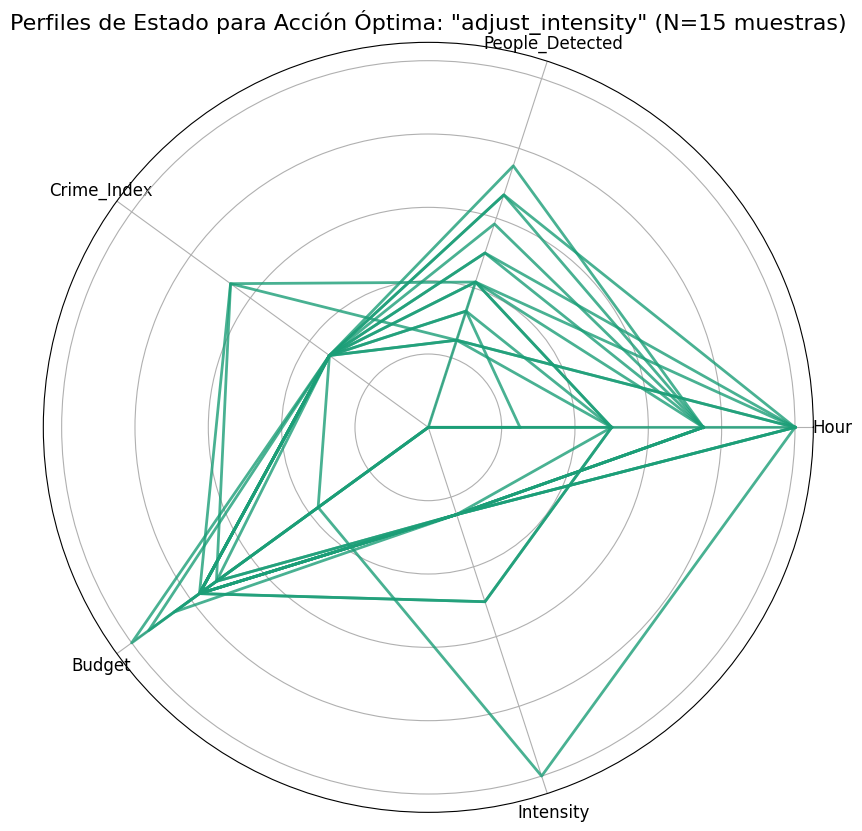

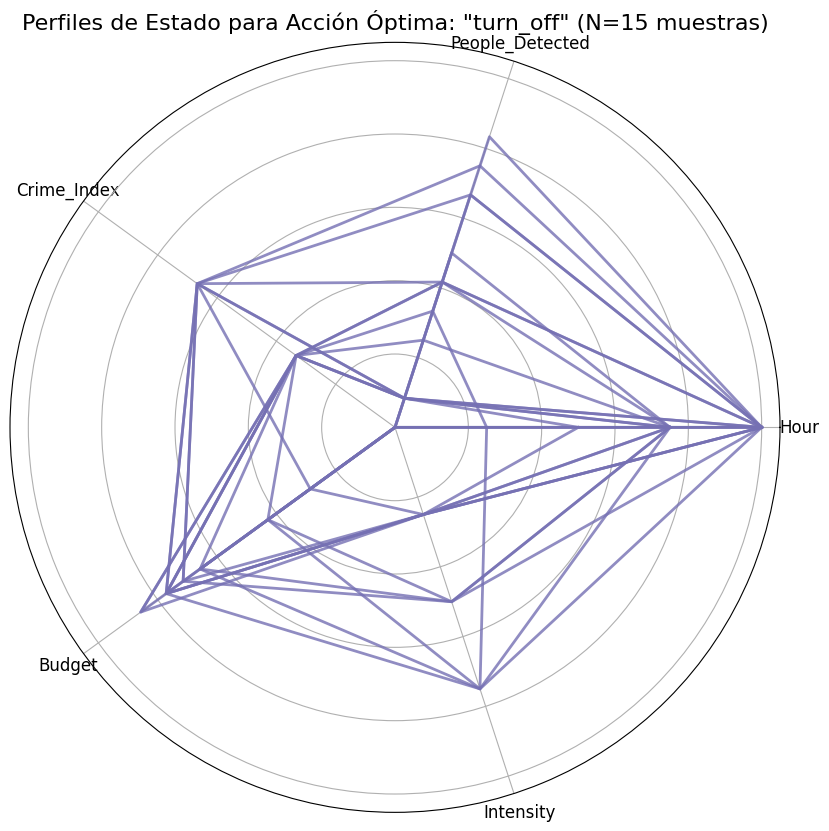

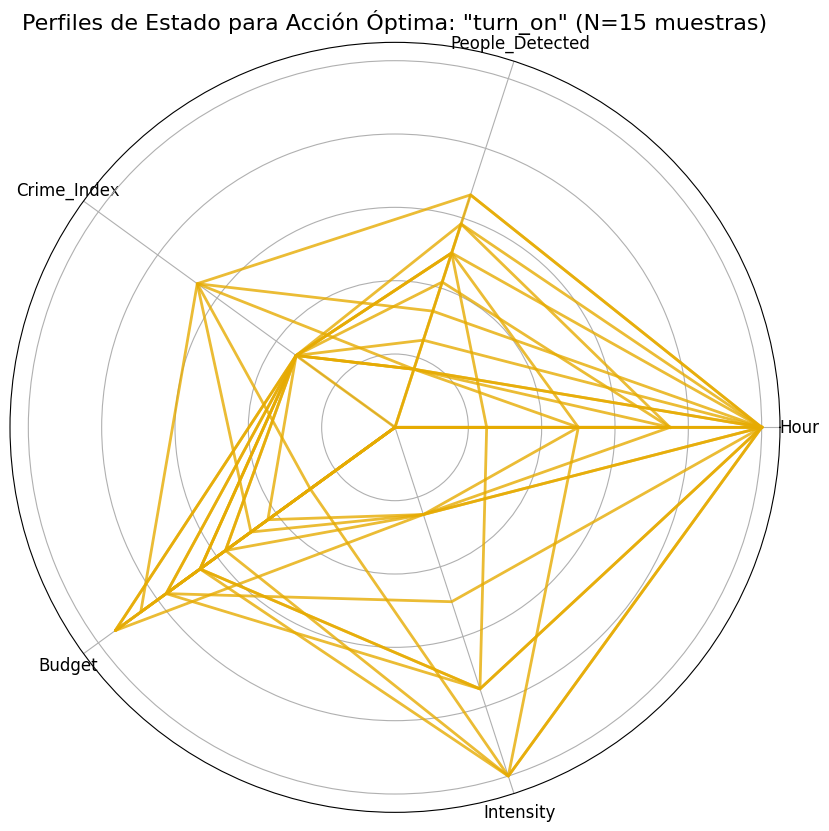

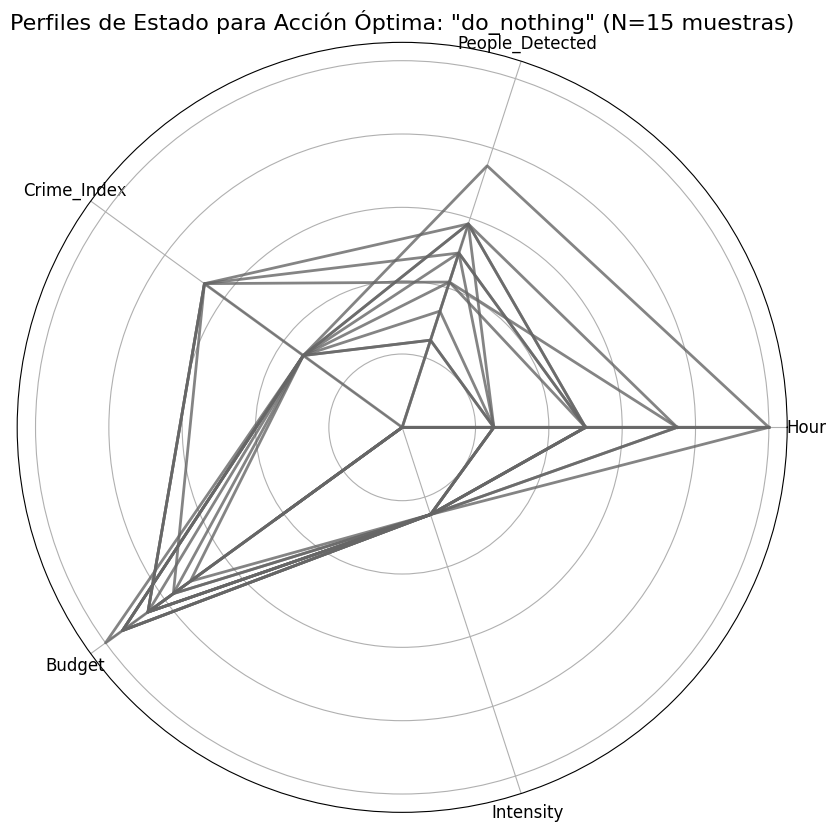

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Seleccionar las características del estado para el radar
features_for_radar = ['Hour', 'People_Detected', 'Crime_Index', 'Budget', 'Intensity']

# Preparar los datos: extraemos solo las características y la acción óptima
data_to_plot = policy_df[features_for_radar + ['Optimal_Action_Type']].copy()

# Normalizar todas las características de forma MIN-MAX a través de TODO el dataset
# Esto es crucial para que cada eje del radar tenga un significado consistente
for feature in features_for_radar:
    min_val = policy_df[feature].min()
    max_val = policy_df[feature].max()
    # Evitar división por cero si una columna tiene un único valor
    if (max_val - min_val) == 0:
        data_to_plot[feature] = 0.5 # Asignar un valor medio si no hay variacion
    else:
        data_to_plot[feature] = (policy_df[feature] - min_val) / (max_val - min_val)


categories = list(features_for_radar)
N = len(categories)

# Calcular el ángulo para cada eje
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Cierra el círculo

cmap = plt.colormaps.get_cmap('Dark2')
optimal_actions = data_to_plot['Optimal_Action_Type'].unique()
num_actions = len(optimal_actions)
colors_map = {action: cmap(i / (num_actions - 1)) if num_actions > 1 else cmap(0.5) for i, action in enumerate(optimal_actions)}


sample_size_per_action = 15 # Triplicar la muestra por acción

for action_type in optimal_actions:
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Seleccionar una muestra aleatoria de estados para esta acción
    action_subset = data_to_plot[data_to_plot['Optimal_Action_Type'] == action_type]
    sampled_states = action_subset.sample(n=min(len(action_subset), sample_size_per_action), random_state=42)

    color = colors_map[action_type]

    for index, row in sampled_states.iterrows():
        values = row[features_for_radar].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2, linestyle='-', alpha=0.8) # Líneas más gruesas

    ax.set_yticklabels([]) # No mostrar etiquetas de escala radial
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)

    ax.set_title(f'Perfiles de Estado para Acción Óptima: "{action_type}" (N={len(sampled_states)} muestras)', va='bottom', fontsize=16)

    plt.show()

In [15]:
from IPython.display import Markdown

# Filtrar el DataFrame para un escenario específico de interés
# Por ejemplo: de noche, con gente presente, y un índice de criminalidad moderado.

scenario_filter = (
    (policy_df['Is_Night'] == True) &
    (policy_df['People_Detected'] > 3) &
    (policy_df['Crime_Index'] > 0.05) &
    (policy_df['Budget'] > 0)
)

scenario_df = policy_df[scenario_filter]

if not scenario_df.empty:
    # Contar las acciones óptimas en este escenario
    action_counts = scenario_df['Optimal_Action_Type'].value_counts()

    print("Acciones óptimas más frecuentes para este escenario:")
    print(action_counts)
    print("\n")

    # Seleccionar la acción más común (o una específica si hay varias) para la narrativa
    most_common_action = action_counts.index[0]

    # Construir la narrativa
    narrative = f"**Recomendación de Política de Iluminación:**\n\nCuando es **de noche**, hay una **cantidad significativa de personas** en el espacio público (más de 3 detectadas) y el **índice de criminalidad es moderado a alto** (mayor a 0.05), el agente de RL recomienda **'{most_common_action}'** las luces para maximizar la recompensa general (considerando seguridad, bienestar y presupuesto)."

    if most_common_action == 'turn_on':
        narrative += " Se prioriza la seguridad y el bienestar percibido ante la presencia de usuarios."
    elif most_common_action == 'adjust_intensity':
        optimal_intensity = scenario_df[scenario_df['Optimal_Action_Type'] == 'adjust_intensity']['Optimal_Action_Value'].mode().iloc[0]
        narrative += f" Se sugiere un ajuste de intensidad a {optimal_intensity}% para equilibrar el ahorro y la necesidad de visibilidad."
    elif most_common_action == 'turn_off':
        narrative += " A pesar de la presencia de personas, el agente puede haber encontrado que apagar las luces es óptimo, posiblemente debido a una alta penalización por consumo de energía o un bajo impacto percibido en la seguridad en las condiciones modeladas, o la ausencia de incidentes recientes."
    elif most_common_action == 'do_nothing':
        narrative += " El agente considera que la configuración actual de las luces es adecuada, evitando cambios innecesarios y optimizando el uso de recursos."

    display(Markdown(narrative))
else:
    print("No se encontraron estados que coincidan con el escenario filtrado.")

Acciones óptimas más frecuentes para este escenario:
Optimal_Action_Type
turn_on             218
turn_off             66
adjust_intensity     36
do_nothing           11
Name: count, dtype: int64




**Recomendación de Política de Iluminación:**

Cuando es **de noche**, hay una **cantidad significativa de personas** en el espacio público (más de 3 detectadas) y el **índice de criminalidad es moderado a alto** (mayor a 0.05), el agente de RL recomienda **'turn_on'** las luces para maximizar la recompensa general (considerando seguridad, bienestar y presupuesto). Se prioriza la seguridad y el bienestar percibido ante la presencia de usuarios.

### Detección de Patrones y Densidad con HDBSCAN y HexBin

In [16]:
import hdbscan
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd

# 1. Preparar y Escalar los datos para HDBSCAN
# Usamos las mismas características numéricas que para el radar, ya que son las que definen el 'estado'
features_for_clustering = ['Hour', 'People_Detected', 'Crime_Index', 'Budget', 'Intensity']
X_clustering = policy_df[features_for_clustering].copy()

# Escalar los datos. HDBSCAN es sensible a la escala de las características.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

print("Datos escalados para HDBSCAN.")

# 2. Aplicar HDBSCAN para el clustering
# `min_cluster_size` define el número mínimo de puntos para formar un cluster.
# `min_samples` influye en lo conservador que es el algoritmo al clasificar los puntos como ruido.
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, prediction_data=True, allow_single_cluster=True)
policy_df['hdbscan_cluster'] = clusterer.fit_predict(X_scaled)

num_clusters = len(policy_df['hdbscan_cluster'].unique()) - (1 if -1 in policy_df['hdbscan_cluster'].unique() else 0)
print(f"HDBSCAN ha identificado {num_clusters} clusters (sin contar el ruido). Datos de cluster añadidos a policy_df.")

# 3. Reducción de Dimensionalidad con UMAP para visualización
# UMAP es excelente para reducir la dimensionalidad manteniendo la estructura de los datos.
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)

# Crear un DataFrame para la visualización 2D
embedding_df = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
embedding_df['hdbscan_cluster'] = policy_df['hdbscan_cluster'] # Añadir las etiquetas de cluster de HDBSCAN

print("Reducción de dimensionalidad con UMAP completada.")


Datos escalados para HDBSCAN.
HDBSCAN ha identificado 1 clusters (sin contar el ruido). Datos de cluster añadidos a policy_df.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reducción de dimensionalidad con UMAP completada.


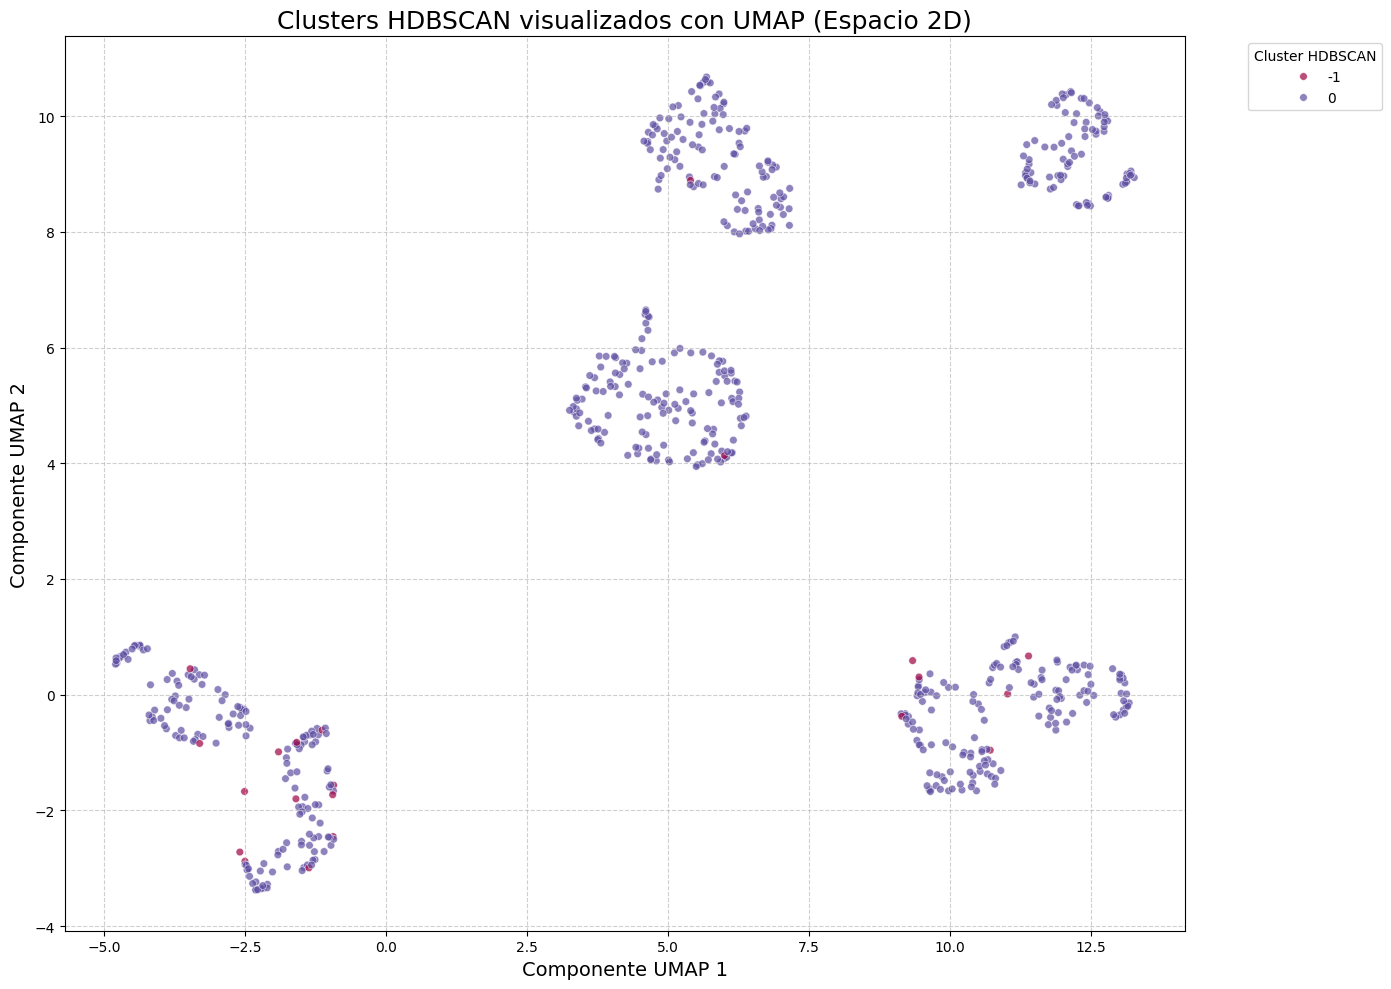

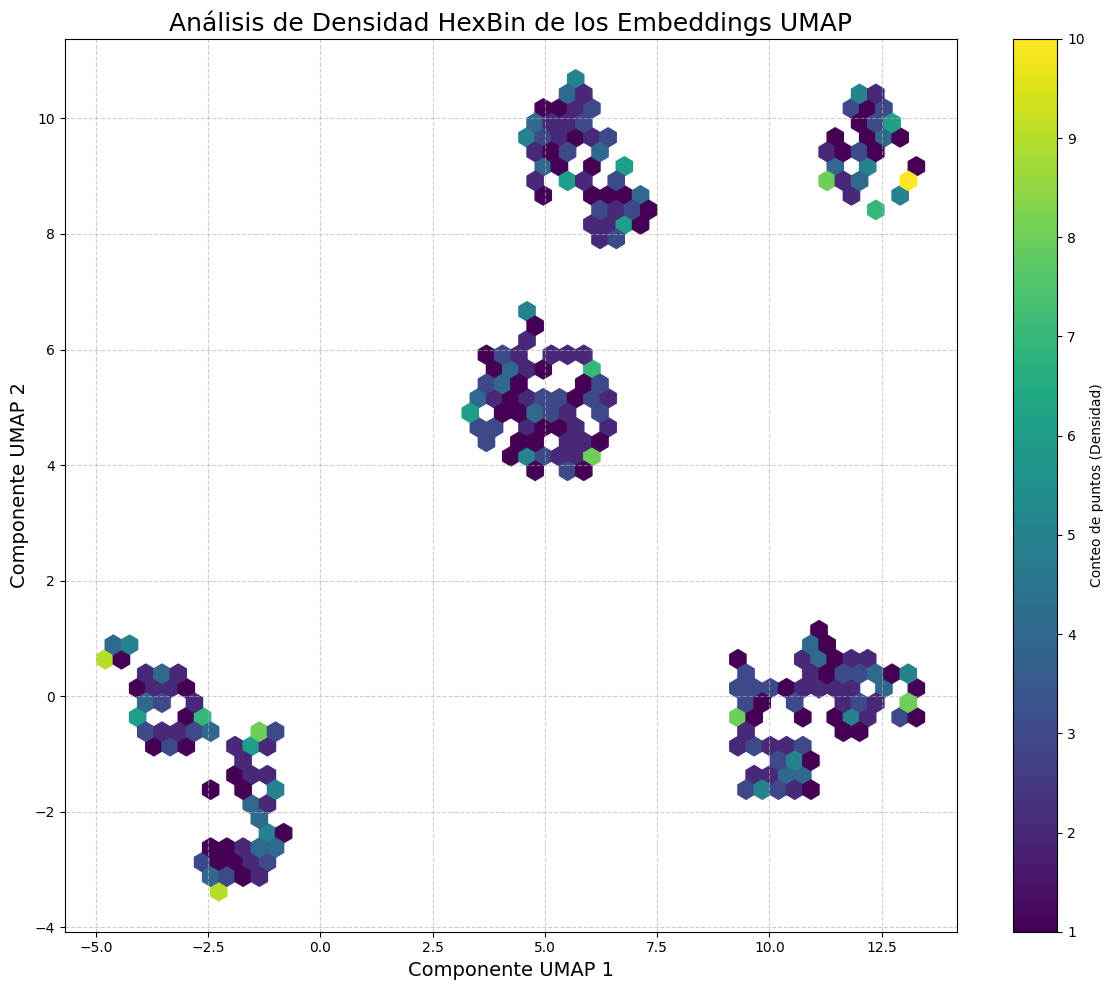

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Visualización de Patrones

# Gráfico de Dispersión (Scatter Plot) de los embeddings UMAP coloreados por cluster HDBSCAN
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='hdbscan_cluster',
    palette='Spectral' if len(embedding_df['hdbscan_cluster'].unique()) > 1 else ['grey'], # Utiliza una paleta si hay múltiples clusters, sino gris
    data=embedding_df,
    s=30, # Tamaño de los puntos
    alpha=0.7 # Transparencia para ver superposiciones
)
plt.title('Clusters HDBSCAN visualizados con UMAP (Espacio 2D)', fontsize=18)
plt.xlabel('Componente UMAP 1', fontsize=14)
plt.ylabel('Componente UMAP 2', fontsize=14)
plt.legend(title='Cluster HDBSCAN', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico HexBin para mostrar la densidad general de los embeddings UMAP
# Esto es útil para ver dónde se concentran más los estados en el espacio 2D
plt.figure(figsize=(12, 10))
plt.hexbin(embedding_df['UMAP_1'], embedding_df['UMAP_2'], gridsize=50, cmap='viridis', mincnt=1)
plt.colorbar(label='Conteo de puntos (Densidad)')
plt.title('Análisis de Densidad HexBin de los Embeddings UMAP', fontsize=18)
plt.xlabel('Componente UMAP 1', fontsize=14)
plt.ylabel('Componente UMAP 2', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

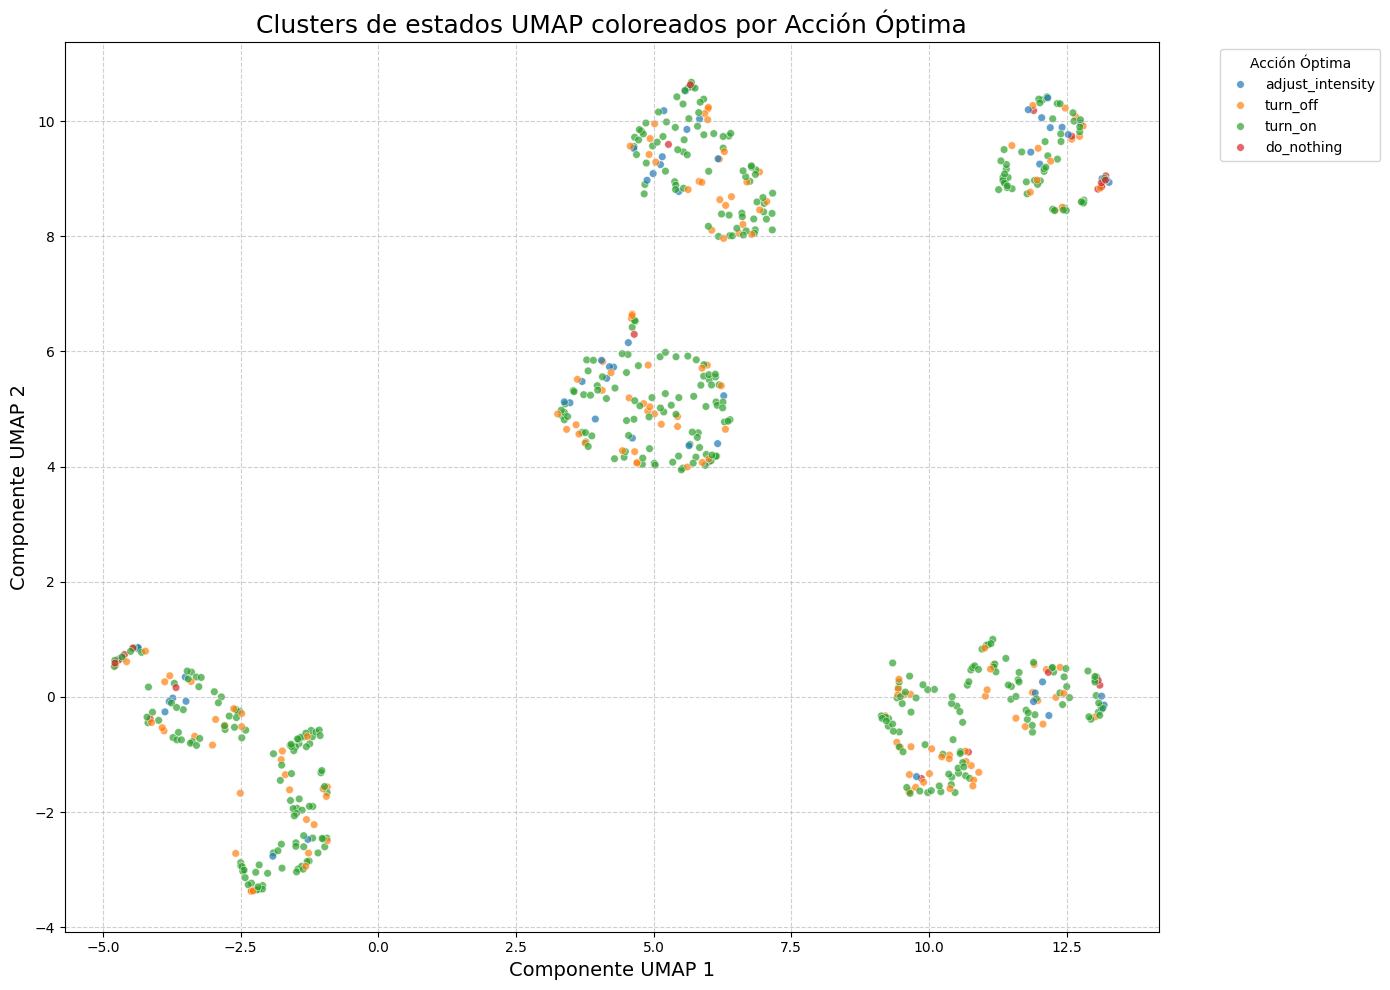

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Añadir la columna 'Optimal_Action_Type' a embedding_df para colorear el scatter plot
embedding_df['Optimal_Action_Type'] = policy_df['Optimal_Action_Type']

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='Optimal_Action_Type', # Colorear por la acción óptima
    palette='tab10', # Usar una paleta de colores para las diferentes acciones
    data=embedding_df,
    s=30, # Tamaño de los puntos
    alpha=0.7 # Transparencia
)
plt.title('Clusters de estados UMAP coloreados por Acción Óptima', fontsize=18)
plt.xlabel('Componente UMAP 1', fontsize=14)
plt.ylabel('Componente UMAP 2', fontsize=14)
plt.legend(title='Acción Óptima', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
print('--- Reporte de Centroides de Clusters HDBSCAN ---')

# Filtrar las características relevantes para el clustering (originales, no escaladas)
features_for_clustering = ['Hour', 'People_Detected', 'Crime_Index', 'Budget', 'Intensity']

# Calcular los centroides (promedios) para cada cluster
cluster_centroids = policy_df.groupby('hdbscan_cluster')[features_for_clustering].mean()

display(cluster_centroids)

# Explicación de los resultados
print('\nInterpretación:')
if -1 in cluster_centroids.index:
    print(f"- El cluster '-1' representa los puntos de ruido o 'outliers' que HDBSCAN no pudo asignar a ningún cluster. Sus valores promedio muestran un perfil de estado que no se ajusta a los patrones densos encontrados.")
    if len(cluster_centroids) > 1:
        main_clusters = cluster_centroids.drop(index=[-1])
        for idx, row in main_clusters.iterrows():
            print(f"- El cluster '{idx}' tiene el siguiente perfil promedio:\n  {row.to_dict()}")
    else:
        print("- Dado que solo se identificó un cluster principal (además del ruido), el perfil de este cluster representa la mayoría de los estados en los que el agente tomó una decisión.")
else:
    for idx, row in cluster_centroids.iterrows():
        print(f"- El cluster '{idx}' tiene el siguiente perfil promedio:\n  {row.to_dict()}")


--- Reporte de Centroides de Clusters HDBSCAN ---


,Hour,People_Detected,Crime_Index,Budget,Intensity
hdbscan_cluster,,,,,
-1,21.619048,5.000000,0.142857,981.047619,48.809524
0,21.210608,4.770671,0.100312,989.257410,43.798752



Interpretación:
- El cluster '-1' representa los puntos de ruido o 'outliers' que HDBSCAN no pudo asignar a ningún cluster. Sus valores promedio muestran un perfil de estado que no se ajusta a los patrones densos encontrados.
- El cluster '0' tiene el siguiente perfil promedio:
  {'Hour': 21.210608424336975, 'People_Detected': 4.770670826833073, 'Crime_Index': 0.10031201248049922, 'Budget': 989.2574102964119, 'Intensity': 43.798751950078}


### Ajuste de Parámetros HDBSCAN para Identificar Múltiples Clusters

In [20]:
import hdbscan
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd

print("Re-ejecutando HDBSCAN con parámetros ajustados...")

# Usamos las mismas características numéricas que antes
features_for_clustering = ['Hour', 'People_Detected', 'Crime_Index', 'Budget', 'Intensity']
X_clustering = policy_df[features_for_clustering].copy()

# Re-escalar los datos por si acaso (aunque X_scaled ya existe del paso anterior)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 2. Aplicar HDBSCAN con parámetros ajustados
# Reducimos min_cluster_size y min_samples para encontrar clusters más pequeños y numerosos
# Por ejemplo, min_cluster_size=5 (mínimo de 5 puntos para formar un cluster) y min_samples=2
clusterer_adjusted = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2, prediction_data=True, allow_single_cluster=True)
policy_df['hdbscan_cluster_adjusted'] = clusterer_adjusted.fit_predict(X_scaled)

num_clusters_adjusted = len(policy_df['hdbscan_cluster_adjusted'].unique()) - (1 if -1 in policy_df['hdbscan_cluster_adjusted'].unique() else 0)
print(f"HDBSCAN con parámetros ajustados ha identificado {num_clusters_adjusted} clusters (sin contar el ruido).")

# Re-generar UMAP embeddings para visualización con los nuevos clusters (aunque el embedding 2D será el mismo, es para consistencia)
reducer_adjusted = umap.UMAP(n_components=2, random_state=42)
embedding_adjusted = reducer_adjusted.fit_transform(X_scaled)

embedding_df_adjusted = pd.DataFrame(embedding_adjusted, columns=['UMAP_1', 'UMAP_2'])
embedding_df_adjusted['hdbscan_cluster_adjusted'] = policy_df['hdbscan_cluster_adjusted'] # Añadir las nuevas etiquetas de cluster
embedding_df_adjusted['Optimal_Action_Type'] = policy_df['Optimal_Action_Type'] # Mantener la acción óptima para colorear

print("Datos re-escalados y UMAP re-generado con nuevas etiquetas de cluster.")

Re-ejecutando HDBSCAN con parámetros ajustados...
HDBSCAN con parámetros ajustados ha identificado 1 clusters (sin contar el ruido).


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Datos re-escalados y UMAP re-generado con nuevas etiquetas de cluster.


### Visualización de UMAP con los Clusters HDBSCAN Ajustados

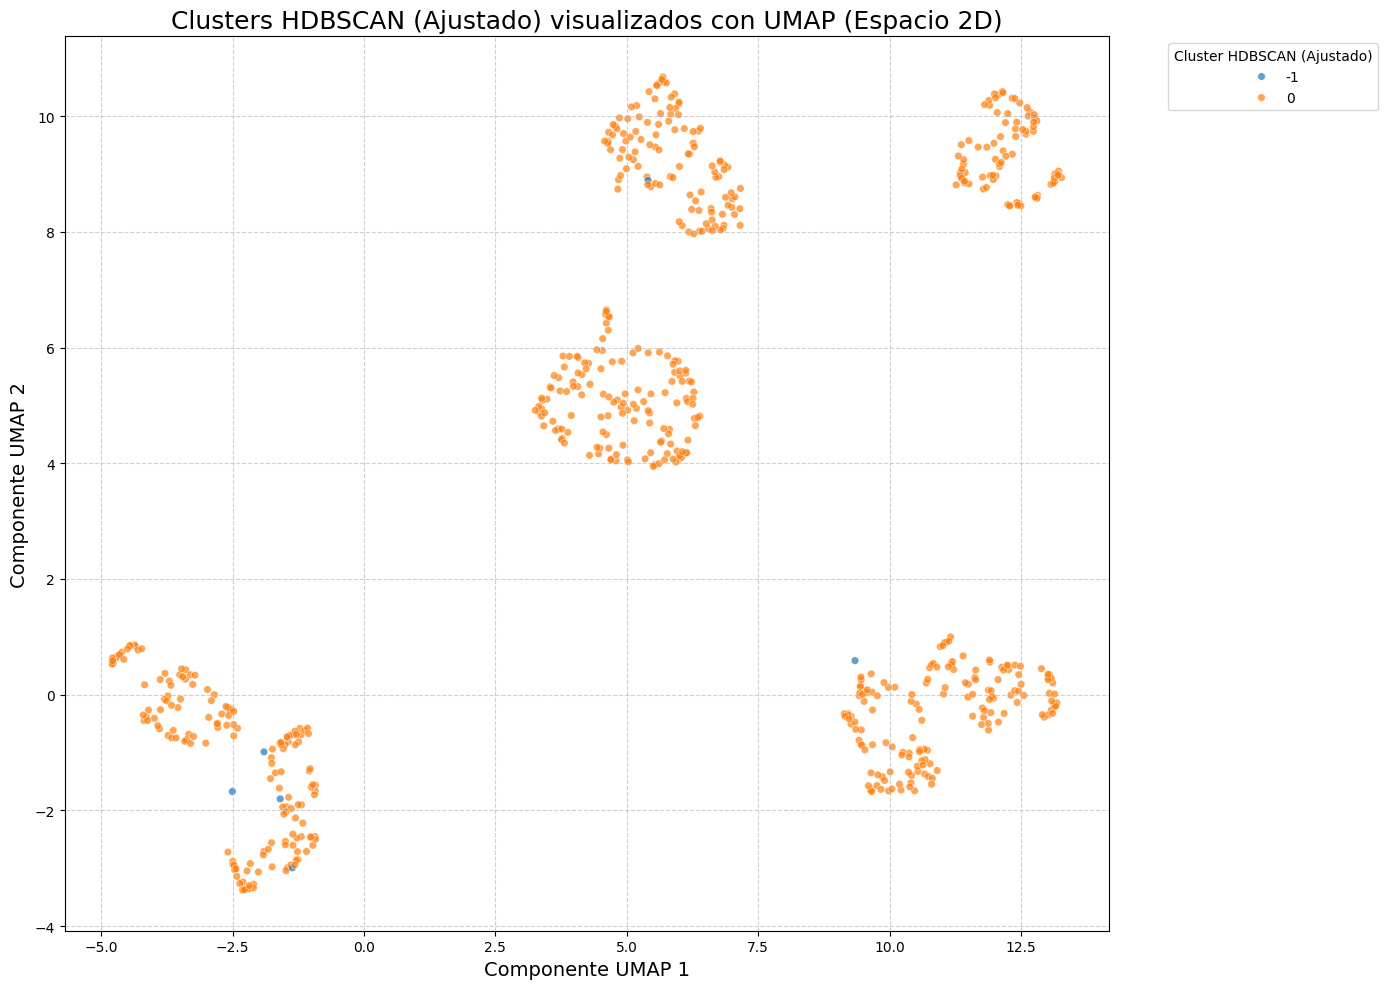

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='hdbscan_cluster_adjusted', # Colorear por los nuevos clusters HDBSCAN
    palette='tab10', # Usar una paleta de colores para los diferentes clusters
    data=embedding_df_adjusted,
    s=30, # Tamaño de los puntos
    alpha=0.7 # Transparencia
)
plt.title('Clusters HDBSCAN (Ajustado) visualizados con UMAP (Espacio 2D)', fontsize=18)
plt.xlabel('Componente UMAP 1', fontsize=14)
plt.ylabel('Componente UMAP 2', fontsize=14)
plt.legend(title='Cluster HDBSCAN (Ajustado)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Reporte de Centroides de los Clusters HDBSCAN Ajustados

In [22]:
print('--- Reporte de Centroides de Clusters HDBSCAN (Ajustado) ---')

# Calcular los centroides (promedios) para cada cluster ajustado
cluster_centroids_adjusted = policy_df.groupby('hdbscan_cluster_adjusted')[features_for_clustering].mean()

display(cluster_centroids_adjusted)

# Explicación de los resultados
print('\nInterpretación:')
if -1 in cluster_centroids_adjusted.index:
    print(f"- El cluster '-1' representa los puntos de ruido o 'outliers' que HDBSCAN no pudo asignar a ningún cluster. Estos puntos no tienen un perfil de estado denso y consistente.")
    main_clusters_adjusted = cluster_centroids_adjusted.drop(index=[-1], errors='ignore')
    if not main_clusters_adjusted.empty:
        for idx, row in main_clusters_adjusted.iterrows():
            print(f"- El Cluster '{idx}' tiene el siguiente perfil promedio de estado:\n  {row.to_dict()}")
    else:
        print("- No se identificaron clusters principales (todos los puntos fueron clasificados como ruido).")
else:
    for idx, row in cluster_centroids_adjusted.iterrows():
        print(f"- El Cluster '{idx}' tiene el siguiente perfil promedio de estado:\n  {row.to_dict()}")
print("\nAnalizar estos centroides nos permitirá entender las características promedio de los estados que definen cada una de las agrupaciones de la política del agente.")

--- Reporte de Centroides de Clusters HDBSCAN (Ajustado) ---


,Hour,People_Detected,Crime_Index,Budget,Intensity
hdbscan_cluster_adjusted,,,,,
-1,21.666667,3.666667,0.183333,980.333333,50.000000
0,21.219512,4.788110,0.100915,989.076220,43.902439



Interpretación:
- El cluster '-1' representa los puntos de ruido o 'outliers' que HDBSCAN no pudo asignar a ningún cluster. Estos puntos no tienen un perfil de estado denso y consistente.
- El Cluster '0' tiene el siguiente perfil promedio de estado:
  {'Hour': 21.21951219512195, 'People_Detected': 4.788109756097561, 'Crime_Index': 0.10091463414634147, 'Budget': 989.0762195121952, 'Intensity': 43.90243902439025}

Analizar estos centroides nos permitirá entender las características promedio de los estados que definen cada una de las agrupaciones de la política del agente.


### Clustering con K-Means para 5 Clusters

Aplicando K-Means con n_clusters=5...
K-Means ha identificado 5 clusters.


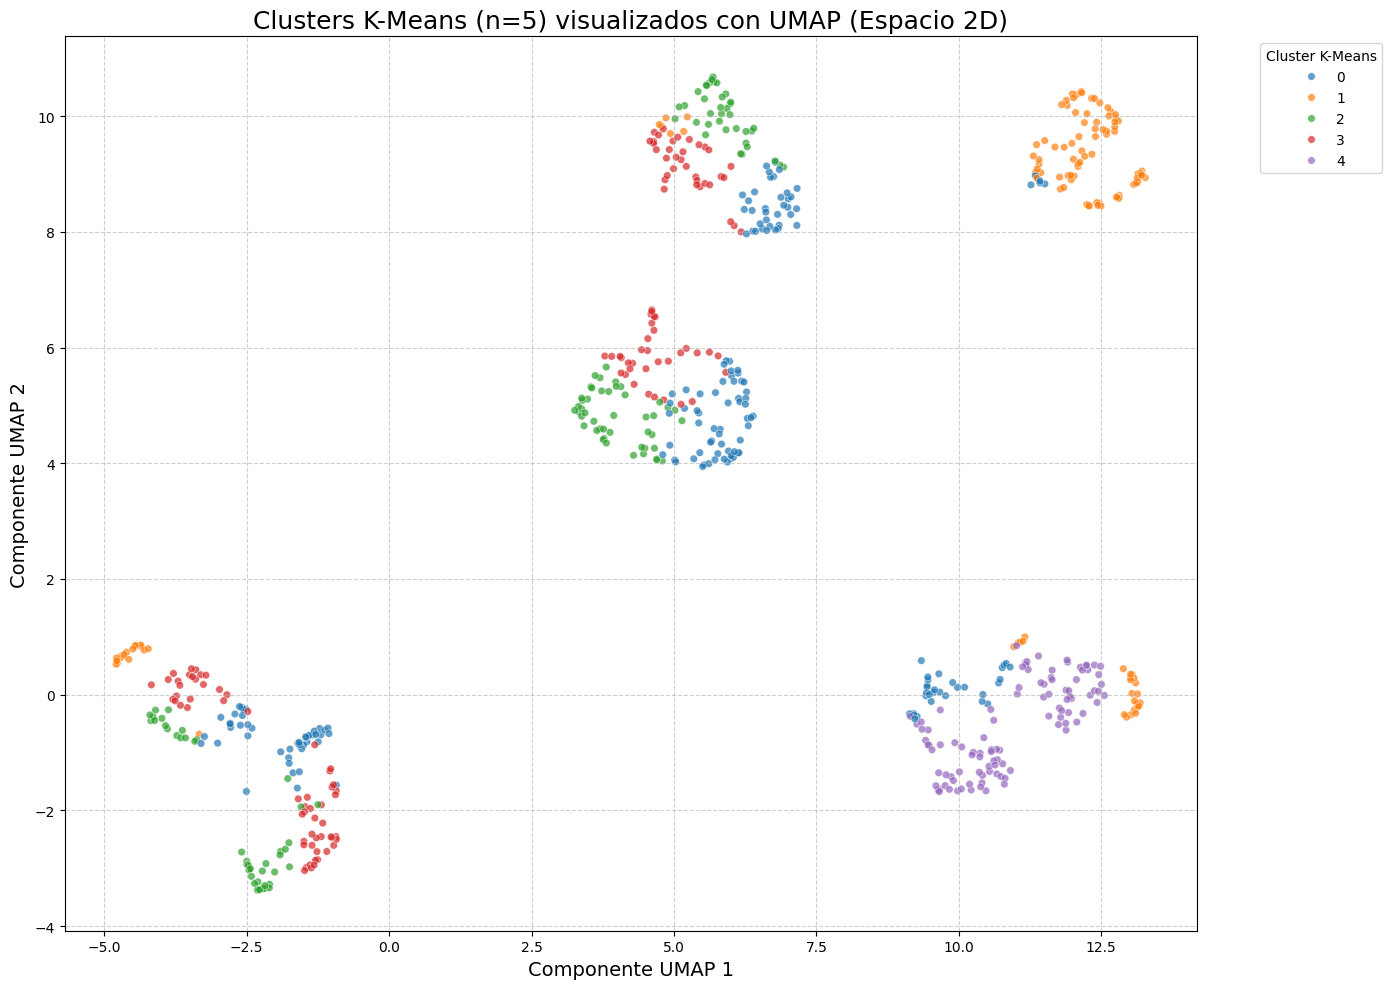

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Aplicando K-Means con n_clusters=5...")

# Usamos los mismos datos escalados que para HDBSCAN
# X_scaled ya debería estar disponible del paso anterior

# Aplicar K-Means
# Para asegurar reproducibilidad, fijamos random_state
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # n_init para evitar problemas con inicializaciones locales
policy_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means ha identificado 5 clusters.")

# Actualizar embedding_df para visualizar los clusters de K-Means
embedding_df_adjusted['kmeans_cluster'] = policy_df['kmeans_cluster']

# Visualización de UMAP con los clusters de K-Means
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='kmeans_cluster', # Colorear por los clusters de K-Means
    palette='tab10', # Usar una paleta de colores para los diferentes clusters
    data=embedding_df_adjusted,
    s=30, # Tamaño de los puntos
    alpha=0.7 # Transparencia
)
plt.title('Clusters K-Means (n=5) visualizados con UMAP (Espacio 2D)', fontsize=18)
plt.xlabel('Componente UMAP 1', fontsize=14)
plt.ylabel('Componente UMAP 2', fontsize=14)
plt.legend(title='Cluster K-Means', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Reporte de Centroides de los Clusters K-Means

In [24]:
print('--- Reporte de Centroides de Clusters K-Means ---')

# Filtrar las características relevantes para el clustering (originales, no escaladas)
features_for_clustering = ['Hour', 'People_Detected', 'Crime_Index', 'Budget', 'Intensity']

# Calcular los centroides (promedios) para cada cluster de K-Means
kmeans_cluster_centroids = policy_df.groupby('kmeans_cluster')[features_for_clustering].mean()

display(kmeans_cluster_centroids)

# Explicación de los resultados
print('\nInterpretación de los Centroides K-Means:')
for idx, row in kmeans_cluster_centroids.iterrows():
    print(f"- El Cluster '{idx}' tiene el siguiente perfil promedio de estado:\n  {row.to_dict()}")
print("\nAnalizar estos centroides nos permitirá caracterizar cada una de las 5 agrupaciones de estados en la política del agente.")

--- Reporte de Centroides de Clusters K-Means ---


,Hour,People_Detected,Crime_Index,Budget,Intensity
kmeans_cluster,,,,,
0,21.563218,4.867816,0.107471,982.022989,86.206897
1,19.861538,4.753846,0.096923,994.776923,35.384615
2,21.582677,2.181102,0.134646,991.015748,22.244094
3,21.546875,7.257812,0.147656,990.054688,28.906250
4,21.524272,4.776699,0.000000,989.679612,28.883495



Interpretación de los Centroides K-Means:
- El Cluster '0' tiene el siguiente perfil promedio de estado:
  {'Hour': 21.563218390804597, 'People_Detected': 4.867816091954023, 'Crime_Index': 0.1074712643678161, 'Budget': 982.0229885057471, 'Intensity': 86.20689655172414}
- El Cluster '1' tiene el siguiente perfil promedio de estado:
  {'Hour': 19.861538461538462, 'People_Detected': 4.753846153846154, 'Crime_Index': 0.09692307692307693, 'Budget': 994.776923076923, 'Intensity': 35.38461538461539}
- El Cluster '2' tiene el siguiente perfil promedio de estado:
  {'Hour': 21.58267716535433, 'People_Detected': 2.1811023622047245, 'Crime_Index': 0.1346456692913386, 'Budget': 991.0157480314961, 'Intensity': 22.244094488188978}
- El Cluster '3' tiene el siguiente perfil promedio de estado:
  {'Hour': 21.546875, 'People_Detected': 7.2578125, 'Crime_Index': 0.14765625000000002, 'Budget': 990.0546875, 'Intensity': 28.90625}
- El Cluster '4' tiene el siguiente perfil promedio de estado:
  {'Hour': 2